# SME(2) vs ML-SME(0,2): velocity profiles in a frictional dam break

Two depth-averaged **shallow-moment** models for the *same* physical dam break:

| model | vertical velocity profile | state |
|---|---|---|
| **SME(2)** | one layer, **3 moments** `q_0,q_1,q_2` → a smooth (quadratic) `u(z)` | `[b, h, q_0, q_1, q_2]` |
| **ML-SME(0,2)** | **2 layers, each constant** (level-0) → a piecewise-constant `u(z)` | `[b, h, q_1_0, q_2_0]` |

The depth-averaged height `h(x)` is almost identical between the two — the
difference lives in the **vertical velocity profile** `u(z)`. To make that
profile non-trivial we switch on **friction** (a Navier-slip bed + bulk
viscosity), which drives vertical shear: the surface moves faster than the
drag-retarded bed. We then **reconstruct `u(z)`** (via the model's
`interpolate_to_3d`) at two locations — left and right of the dam — and
compare SME(2)'s smooth profile to ML-SME(0,2)'s two constant layers.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from zoomy_core.model.models import SME, MLSME
from zoomy_core.model.models.closures import Newtonian, NavierSlip, StressFree
from zoomy_core.mesh import BaseMesh
import zoomy_core.model.initial_conditions as IC
from zoomy_core.model.boundary_conditions import BoundaryConditions, Extrapolation
import zoomy_core.fvm.timestepping as timestepping
from zoomy_core.fvm.solver_numpy import HyperbolicSolver
from zoomy_core.numerics import NumericalSystemModel, ReconstructionSpec
from zoomy_core.misc.misc import Settings, Zstruct
import zoomy_plotting as zp

zp.apply_style()

ART = os.path.abspath("_artifacts")
os.makedirs(ART, exist_ok=True)

DOMAIN = (0.0, 10.0)
NC = 200
X_DAM = 5.0
H_L, H_R = 2.0, 1.0
T_END = 2.0
SNAPS = 40
IH = 1                                   # height h is state index 1 (both models)

# Friction closures: viscous bulk (Newtonian ν) + Navier-slip bed (λ_s).
# Smaller λ_s = more bed drag → more shear.  These two parameters are what
# make SME(2) and ML-SME(0,2) differ in the velocity profile.
FRICTION = dict(nu=0.05, lambda_s=0.05)
CLOSURES = [Newtonian(), NavierSlip(), StressFree()]
X_PROBES = [3.0, 7.0]                     # left / right of the dam

## Driver (identical for both models, friction on)

In [2]:
def run_dambreak(sm, name):
    n_state = len(sm.state)

    def ic(x):
        out = np.zeros(n_state)
        out[IH] = H_L if float(x[0]) < X_DAM else H_R
        return out

    sm.initial_conditions = IC.UserFunction(function=ic)
    sm.aux_initial_conditions = IC.Constant(constants=lambda n: np.zeros(n))
    mesh = BaseMesh.create_1d(domain=DOMAIN, n_inner_cells=NC)
    nsm = NumericalSystemModel.from_system_model(
        sm, reconstruction=ReconstructionSpec(order=1))
    solver = HyperbolicSolver(
        time_end=T_END, compute_dt=timestepping.adaptive(CFL=0.4),
        settings=Settings(name=name, output=Zstruct(
            directory=ART, filename=name, snapshots=SNAPS,
            clean_directory=True)))
    solver.solve(mesh, nsm, write_output=True)
    return zp.read(os.path.join(ART, name + ".h5"))


sme = SME(
    closures=CLOSURES, level=2, parameters=FRICTION,
    boundary_conditions=BoundaryConditions(
        [Extrapolation(tag="left"), Extrapolation(tag="right")])).system_model
mlsme = MLSME(
    closures=CLOSURES, level=0, n_layers=2, interface_velocity="mean",
    parameters=FRICTION,
    boundary_conditions=BoundaryConditions(
        [Extrapolation(tag="left"), Extrapolation(tag="right")])).system_model

print("SME(2)      state:", [str(s) for s in sme.state])
print("ML-SME(0,2) state:", [str(s) for s in mlsme.state])

store_sme = run_dambreak(sme, "sme2")
store_ml = run_dambreak(mlsme, "mlsme02")

SME(2)      state: ['b', 'h', 'q_0', 'q_1', 'q_2']
ML-SME(0,2) state: ['b', 'h', 'q_1_0', 'q_2_0']


2026-06-16 13:15:18.277 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 10, time: 0.021421, dt: 0.002064, next write at time: 0.051282


2026-06-16 13:15:18.377 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 20, time: 0.041712, dt: 0.002005, next write at time: 0.051282


2026-06-16 13:15:18.485 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 30, time: 0.061640, dt: 0.001987, next write at time: 0.102564


2026-06-16 13:15:18.586 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 40, time: 0.081462, dt: 0.001979, next write at time: 0.102564


...

2026-06-16 13:15:32.769 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 980, time: 1.938307, dt: 0.001981, next write at time: 1.948718


2026-06-16 13:15:32.811 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 990, time: 1.958119, dt: 0.001981, next write at time: 2.000000


2026-06-16 13:15:32.846 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 1000, time: 1.977932, dt: 0.001981, next write at time: 2.000000


2026-06-16 13:15:32.881 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1147 - iteration: 1010, time: 1.997748, dt: 0.001982, next write at time: 2.000000


2026-06-16 13:15:32.890 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1153 - Finished simulation with in 3.842 seconds


## Reconstruct the vertical velocity profile `u(z)`

`interpolate_to_3d` lifts the depth-averaged state to the canonical 3-D
profile `[b, h, u, v, w, p](z)`; row 2 is the horizontal velocity `u(z)`,
`z ∈ [0,1]` from bed to surface.  We lambdify it once per model and evaluate
at a given cell's state.

In [3]:
def make_u_of_z(sm):
    """Return f(Q_cell, z_grid) -> u(z) for this model's interpolate_to_3d."""
    u_row = sp.sympify(list(sm.interpolate_to_3d)[2])          # canonical row 2 = u
    args = list(sm.state) + list(sm.aux_state) + list(sm.parameters) + [sp.Symbol("z")]
    fn = sp.lambdify(args, u_row, "numpy")
    n_aux = len(sm.aux_state)
    pvals = [float(v) for v in sm.parameter_values.values()]   # g, ρ, ν, λ_s, …

    def u_of_z(Q_cell, z_grid):
        return np.array([float(np.ravel(fn(*Q_cell, *([0.0] * n_aux),
                                           *pvals, float(z)))[0])
                         for z in z_grid])
    return u_of_z


def state_at_cell(store, sm, t, cell):
    return [np.asarray(store.get_cell(t, i)).ravel()[cell]
            for i in range(len(sm.state))]


u_sme = make_u_of_z(sme)
u_ml = make_u_of_z(mlsme)
x = np.asarray(store_sme.cell_centers).ravel()[:NC]
probe_cells = [int(np.argmin(np.abs(x - xp))) for xp in X_PROBES]
zeta = np.linspace(0.0, 1.0, 41)
t_last = store_sme.n_snapshots - 1

## Compare: `h(x)` with the two probes, and `u(z)` at each probe

In [4]:
fig, axes = plt.subplot_mosaic(
    [["h", "h"], ["pL", "pR"]], figsize=(9, 7),
    height_ratios=[1, 2.2])

# top: surface height with the two probe locations
axes["h"].plot(x, np.asarray(store_sme.get_cell(t_last, IH)).ravel()[:NC],
               label="SME(2)")
axes["h"].plot(x, np.asarray(store_ml.get_cell(t_last, IH)).ravel()[:NC], "--",
               label="ML-SME(0,2)")
for xp in X_PROBES:
    axes["h"].axvline(xp, color="0.6", lw=1, ls=":")
axes["h"].set(xlabel="x [m]", ylabel="h [m]",
              title=f"surface height, t = {T_END} s")
axes["h"].legend(loc="upper right")

# bottom: u(z) profiles at the two probes (z vertical, u horizontal)
for key, cell, xp in zip(("pL", "pR"), probe_cells, X_PROBES):
    ax = axes[key]
    Qs = state_at_cell(store_sme, sme, t_last, cell)
    Qm = state_at_cell(store_ml, mlsme, t_last, cell)
    ax.plot(u_sme(Qs, zeta), zeta, label="SME(2)")
    ax.plot(u_ml(Qm, zeta), zeta, "--", label="ML-SME(0,2)")
    ax.set(xlabel="u [m/s]", ylabel="z  (0 = bed, 1 = surface)",
           title=f"velocity profile at x = {xp:.0f} m")
    ax.legend(loc="lower right")

fig.suptitle("SME(2) vs ML-SME(0,2): vertical velocity profiles (with slip friction)")
fig.tight_layout()
fig.savefig(os.path.join(ART, "velocity_profiles.png"), dpi=130)

The bed drag (Navier slip) retards the near-bed velocity and the surface runs
faster — the shear the depth-averaged `h(x)` cannot show. **SME(2)** renders it
as a smooth moment profile; **ML-SME(0,2)** as two constant layers. With more
layers / higher moment order both converge to the same resolved profile.

## (optional) animate the profiles developing

`zoomy_plotting.animate` over the snapshots — the shear growing in time.

In [5]:
def draw(fig, t):
    (axL, axR) = fig.subplots(1, 2)
    for ax, cell, xp in zip((axL, axR), probe_cells, X_PROBES):
        Qs = state_at_cell(store_sme, sme, t, cell)
        Qm = state_at_cell(store_ml, mlsme, t, cell)
        ax.plot(u_sme(Qs, zeta), zeta, label="SME(2)")
        ax.plot(u_ml(Qm, zeta), zeta, "--", label="ML-SME(0,2)")
        ax.set(xlabel="u [m/s]", ylabel="z", title=f"x = {xp:.0f} m",
               xlim=(-0.2, 2.0))
        ax.legend(loc="lower right")
    fig.suptitle(f"velocity profiles, t = {t / (store_sme.n_snapshots - 1) * T_END:.2f} s")


gif = zp.animate(draw, range(store_sme.n_snapshots),
                 os.path.join(ART, "velocity_profiles.gif"), fps=10,
                 figsize=(9, 4))

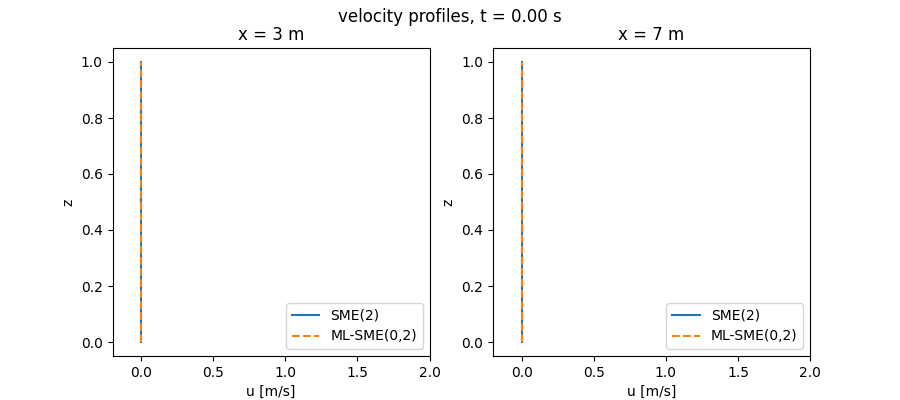

In [6]:
from IPython.display import Image  # noqa: E402

Image(filename=gif)